# Replicate 2 - Prototype Replication Deconvolution

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from pipeline.fit_replication_profiles import main

# Running from the parameter fits from a few months ago to compare
# the convergence speed and values from a cold start from the CLOCCS posteriors
parameter_updates_df, optimizer, replication_deconvolver = main(chrom=4, replicate=2,
    num_epochs=2, from_CLOCCS=True)


Loading initial cell cycle parameters from CLOCCS fits.
Shifting mu0, gamma1, and gamma2, for alpha...
Threshold windows with less than 75% read coverage.
Running initial iterations...
Initializing N using config H.
Initializing B using timepoint 0
Done.
Initial config parameters:              value    min   max
mu0     -0.151000 -30.00  30.0
delta   10.895300   0.00  24.0
sigma0  10.631000   1.00  14.0
sigmav   0.129700   0.01   1.0
lambda  60.209300  40.00  80.0
gamma1   0.333875   0.00   1.0
gamma2   0.615875   0.00   1.0
halted   0.290600   0.00   1.0
Running 2 epochs...
Epoch: 0
Optimization [1]: Current loss: 0.002843571356447086
Optimization [101]: Current loss: 0.002780945604744209
Optimization [201]: Current loss: 0.002778419451897391
Optimization [301]: Current loss: 0.00277827489809448
Optimization [401]: Current loss: 0.0027778412968730375
Optimization [501]: Current loss: 0.0027712521042095963
Optimization [601]: Current loss: 0.0027455499176861123
Optimization [701]: Curr

In [16]:
replication_deconvolver.G_df.shape, replication_deconvolver.masked_G_df.shape

((15, 761), (15, 704))

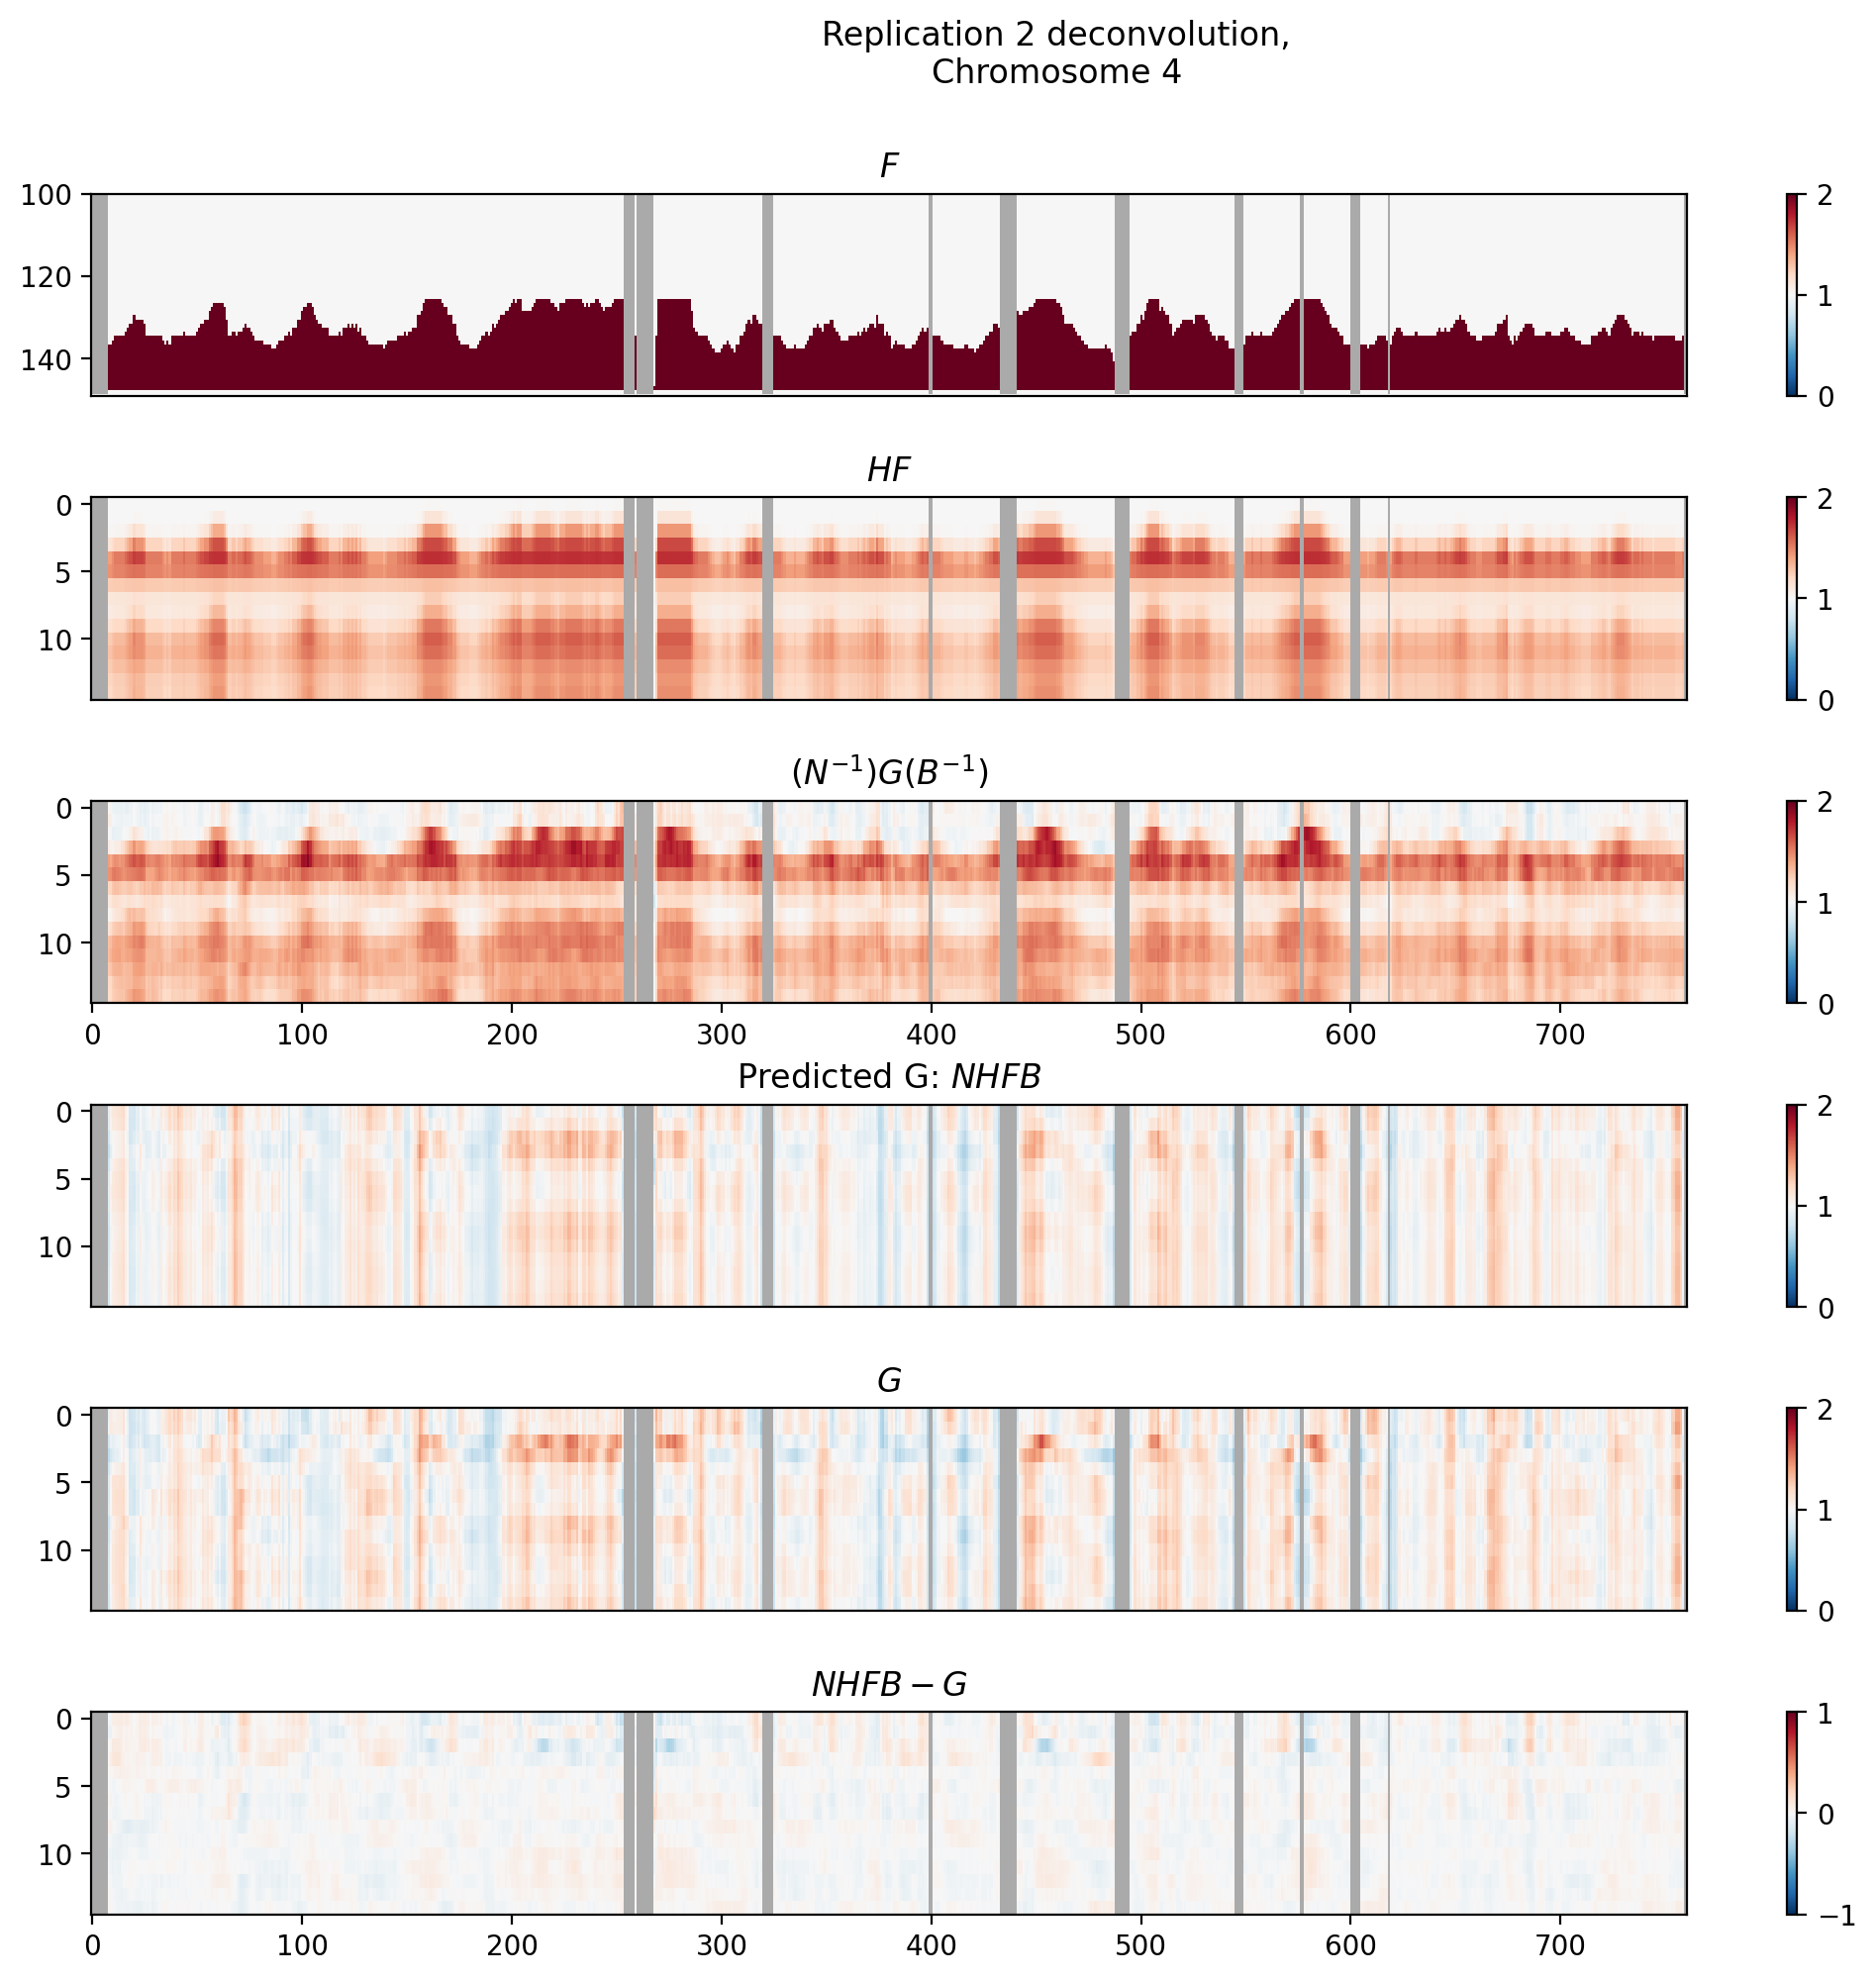

In [3]:
fig = replication_deconvolver.plot_heatmaps()

In [29]:
from src.config import load_default_chrom_configs

config1, config2 = load_default_chrom_configs(from_CLOCCS=True)

# Load the replicate 1 and 2 parameters and deconvolve combined

params_rep1 = pd.read_csv('output/prototype_pipeline_subset/parameter_updates_rep1_chr4.csv')
parameters = params_rep1.iloc[-1]

mu0, gamma1, gamma2, sigma0 = parameters.mu0, parameters.gamma1, \
    parameters.gamma2, parameters.sigma0
mu0, gamma1, gamma2, sigma0

config1.params_dic['mu0'] = mu0
config1.params_dic['gamma1'] = gamma1
config1.params_dic['gamma2'] = gamma2
config1.params_dic['sigma0'] = sigma0
config1.params_dic['alpha'] = 0
config1.update_timepoints()
H1 = config1.calculate_H()
config1.params_dic

Shifting mu0, gamma1, and gamma2, for alpha...


{'mu0': 13.549227083922458,
 'delta': 8.1805,
 'sigma0': 3.656160348296892,
 'sigmav': 0.1424,
 'lambda': 68.1914,
 'gamma1': 0.5590209539125397,
 'gamma2': 1.0,
 'halted': 0.2245,
 'alpha': 0}

In [73]:
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.optimize_H import create_bounds_params_from_config

replication_deconvolver = RealDataReplicationDeconvolution(config1, 
    replicate=1, chr=4)

Omit windows with less than 75% read coverage.


In [81]:
F, N, B = load_from_save('output/prototype_pipeline_subset', 1, 4)

In [82]:
# First iteration to settle N, Fr, and B
replication_deconvolver.setup_deconvolution(config1, initial_N=N, initial_B=B)

Initializing N using config H.
Deconvolving 702 regions


In [83]:
replication_deconvolver.iterative_deconvolution_updates(1, verbose=True)

[0] 00:00:00.339, rn=0.005935088889076371


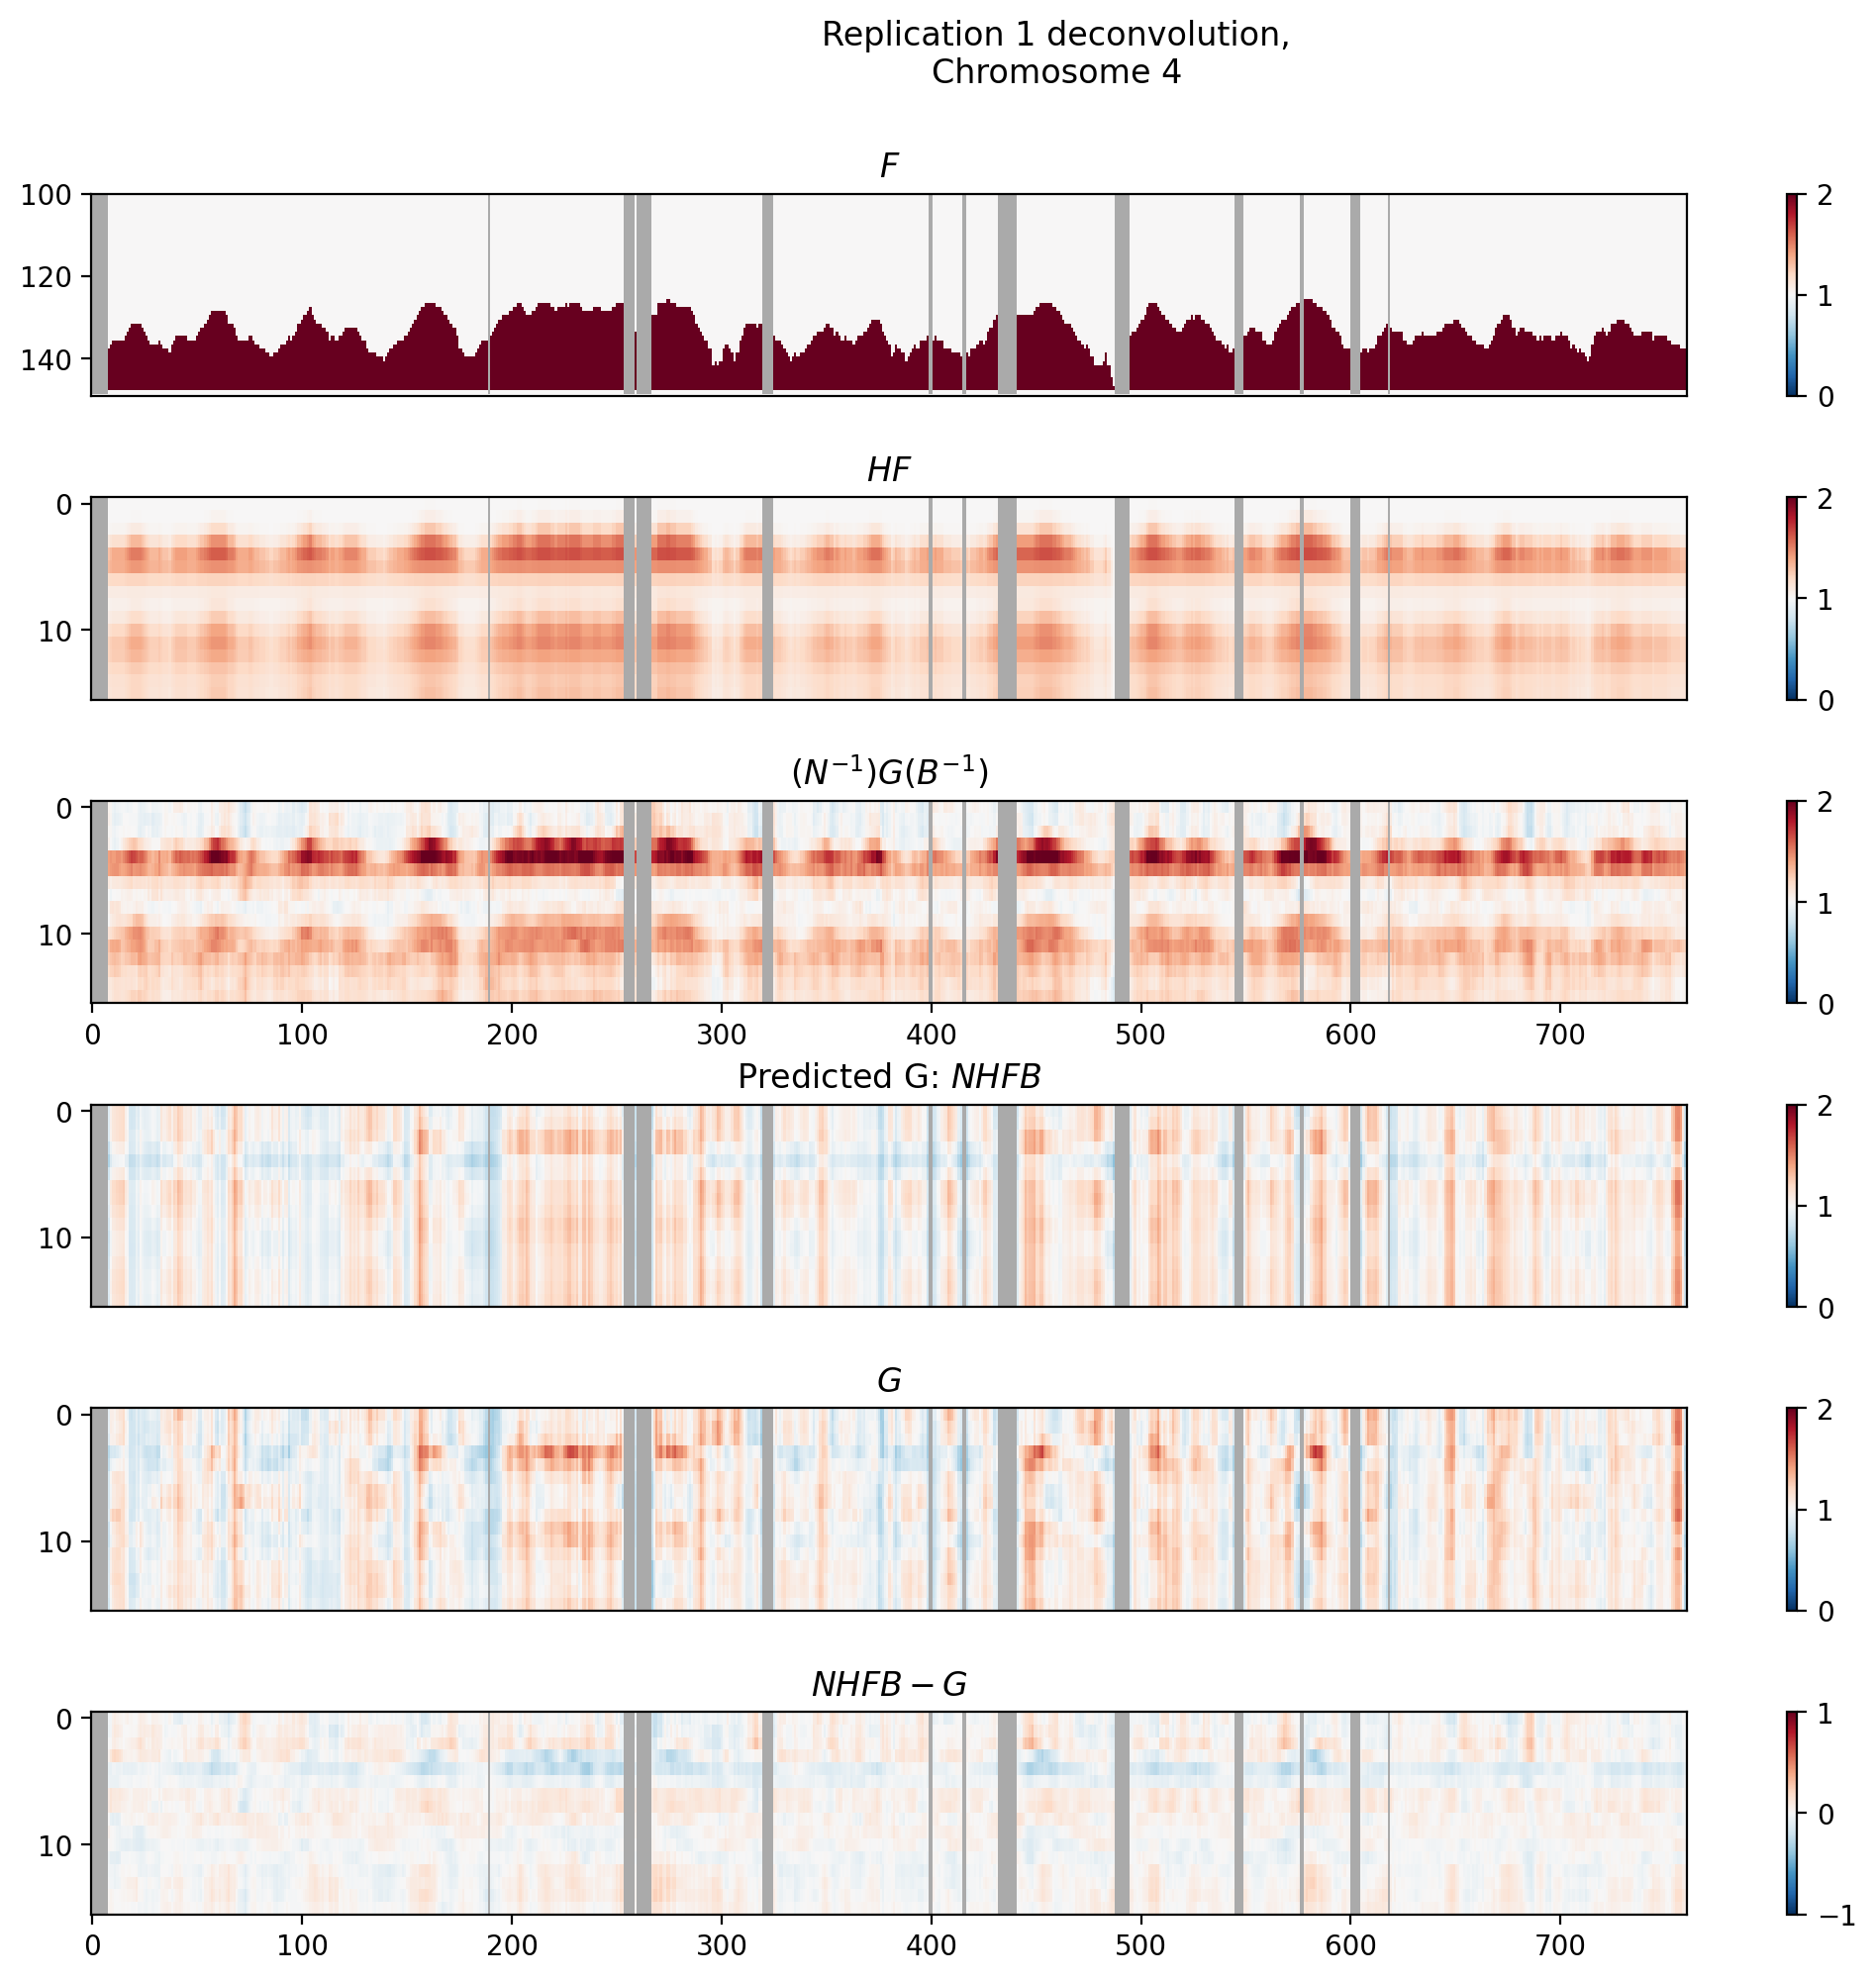

In [84]:
fig = replication_deconvolver.plot_heatmaps()

In [ ]:
# Idea, second stage to learn delta and lambda...



